# Homework 04: Building CNNs for Image Classification

## Due: Midnight on February 15 (with 2-hour grace period) and worth 85 points

In this assignment, you will take your first steps into designing and training convolutional neural networks (CNNs) for image classification. Starting from a simple baseline, you will experiment with modifications that reflect the kinds of design choices practitioners face every day. Along the way, you’ll see how architecture, hyperparameters, normalization, pooling strategies, and learning rate schedules can each shape a model’s performance.

The problems are organized to build on each other:

1. **Hyperparameters:** Begin with a baseline CNN and try variations in learning rate, layer width, depth, and dropout.
2. **Batch Normalization:** Add normalization after convolutional layers to stabilize training and speed convergence.
3. **Global Average Pooling:** Replace the flatten-and-dense head with a modern pooling layer, reducing parameters and improving generalization.
4. **ReduceLROnPlateau:** Explore a widely used learning rate scheduler that adapts when validation progress slows.
5. **Very Deep CNN:** Finally, run a VGG-16–style model to observe how deeper networks behave compared to smaller ones.

By the end of this homework, you will have hands-on experience with both classical and modern CNN design strategies, a sense of how different components affect learning, and a toolkit of techniques that will serve you in future image processing projects. 

There are 10 graded questions, worth 8 points each, with 5 points free if you complete all of the graded questions in the homework. 


In [2]:

import os, random, time
import numpy as np
import tensorflow as tf
import kagglehub
from tensorflow.keras.utils import image_dataset_from_directory

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

# Settings
img_size = (96, 96)
batch_size = 32

# Download + paths
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

print("train_dir exists?", os.path.exists(train_dir))
print("test_dir exists? ", os.path.exists(test_dir))

# Load datasets
trainval_raw = image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=random_seed
)

test_raw = image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# Save class names BEFORE mapping/prefetch
class_names = trainval_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Normalize + prefetch
def norm(x, y):
    return tf.cast(x, tf.float32) / 255.0, y

trainval_ds = trainval_raw.map(norm).prefetch(tf.data.AUTOTUNE)
test_ds     = test_raw.map(norm).prefetch(tf.data.AUTOTUNE)

# Train/val split by batches
card = tf.data.experimental.cardinality(trainval_ds).numpy()
val_batches = max(1, int(0.2 * card))
val_ds   = trainval_ds.take(val_batches)
train_ds = trainval_ds.skip(val_batches)

print("batches - train:", tf.data.experimental.cardinality(train_ds).numpy(),
      "val:", tf.data.experimental.cardinality(val_ds).numpy(),
      "test:", tf.data.experimental.cardinality(test_ds).numpy())
# --------------------------------------------


2026-02-18 00:19:38.679250: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-18 00:19:40.549932: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-18 00:19:46.269899: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train_dir exists? True
test_dir exists?  True
Found 14034 files belonging to 6 classes.


2026-02-18 00:19:53.608646: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
batches - train: 352 val: 87 test: 94


In [3]:
import matplotlib.pyplot as plt

results = {}

def plot_learning_curves(hist, title, verbose=True):
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss, min_val_epoch + 1)

def print_results():
    for title, (acc, ep) in sorted(results.items(), key=lambda kv: kv[1][0], reverse=True):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")


In [4]:
def train_and_test_ds(model, title="Model", epochs=12, lr=1e-3, verbose=2, extra_callbacks=None):
    if extra_callbacks is None:
        extra_callbacks = []

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early] + extra_callbacks,
        verbose=verbose
    )

    plot_learning_curves(history, title=title)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Accuracy: {test_acc:.4f}")
    return history, float(test_acc)


Epoch 1/12


2026-02-18 00:20:41.320019: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37748736 exceeds 10% of free system memory.
2026-02-18 00:20:41.824717: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18874368 exceeds 10% of free system memory.
2026-02-18 00:20:42.013784: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18874368 exceeds 10% of free system memory.
2026-02-18 00:20:42.129997: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 26542080 exceeds 10% of free system memory.
2026-02-18 00:20:42.327902: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 18874368 exceeds 10% of free system memory.


352/352 - 121s - 344ms/step - accuracy: 0.3380 - loss: 1.6264 - val_accuracy: 0.3822 - val_loss: 1.4418
Epoch 2/12
352/352 - 105s - 298ms/step - accuracy: 0.4601 - loss: 1.2827 - val_accuracy: 0.5819 - val_loss: 1.1223
Epoch 3/12
352/352 - 105s - 299ms/step - accuracy: 0.5239 - loss: 1.1235 - val_accuracy: 0.6609 - val_loss: 0.9434
Epoch 4/12
352/352 - 104s - 297ms/step - accuracy: 0.5948 - loss: 1.0078 - val_accuracy: 0.7209 - val_loss: 0.8045
Epoch 5/12
352/352 - 107s - 305ms/step - accuracy: 0.6523 - loss: 0.9075 - val_accuracy: 0.7320 - val_loss: 0.7650
Epoch 6/12
352/352 - 104s - 295ms/step - accuracy: 0.6935 - loss: 0.8152 - val_accuracy: 0.7748 - val_loss: 0.6653
Epoch 7/12
352/352 - 104s - 296ms/step - accuracy: 0.7137 - loss: 0.7558 - val_accuracy: 0.7863 - val_loss: 0.6304
Epoch 8/12
352/352 - 104s - 296ms/step - accuracy: 0.7475 - loss: 0.6686 - val_accuracy: 0.7917 - val_loss: 0.6123
Epoch 9/12
352/352 - 104s - 296ms/step - accuracy: 0.7708 - loss: 0.6045 - val_accuracy: 0.

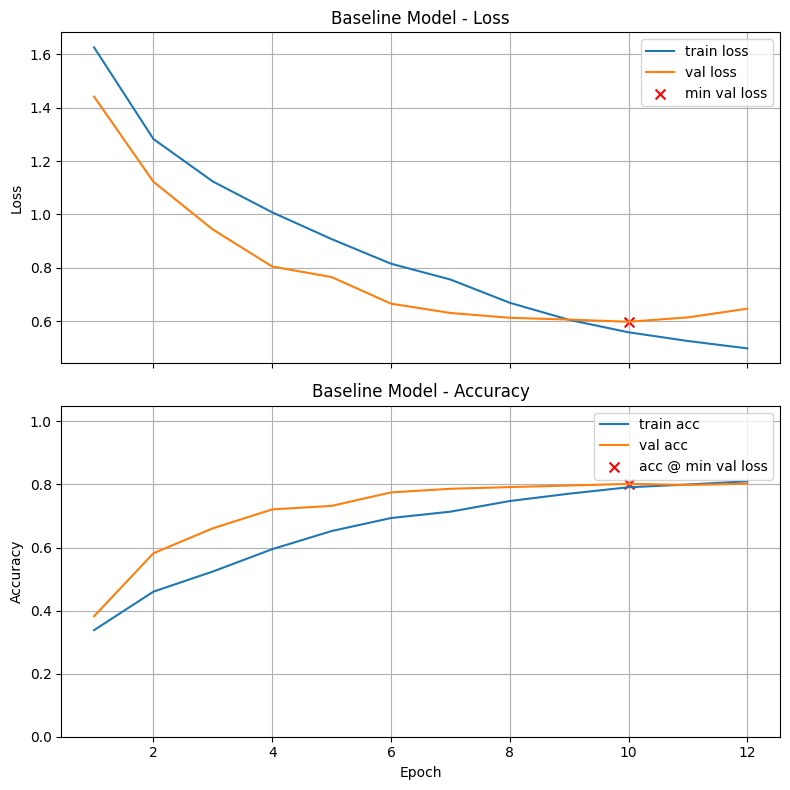

Final Training Loss:            0.4976
Final Training Accuracy:        0.8099
Final Validation Loss:          0.6465
Final Validation Accuracy:      0.8024
Minimum Validation Loss:        0.5975 (Epoch 10)
Validation Accuracy @ Min Loss: 0.8017

Test Accuracy: 0.7950
Baseline Model                          	0.8017	10


In [5]:
he = tf.keras.initializers.HeNormal()

model_baseline = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_size[0], img_size[1], 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu", kernel_initializer=he),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

history_base, test_acc_base = train_and_test_ds(
    model_baseline,
    title="Baseline Model",
    epochs=12,
    lr=1e-3,
    verbose=2
)

print_results()


Epoch 1/12
352/352 - 113s - 322ms/step - accuracy: 0.2547 - loss: 1.7081 - val_accuracy: 0.4458 - val_loss: 1.5414
Epoch 2/12
352/352 - 114s - 324ms/step - accuracy: 0.3134 - loss: 1.5836 - val_accuracy: 0.4921 - val_loss: 1.4008
Epoch 3/12
352/352 - 115s - 327ms/step - accuracy: 0.3442 - loss: 1.5124 - val_accuracy: 0.5456 - val_loss: 1.3338
Epoch 4/12
352/352 - 117s - 331ms/step - accuracy: 0.3838 - loss: 1.4576 - val_accuracy: 0.5377 - val_loss: 1.2915
Epoch 5/12
352/352 - 119s - 337ms/step - accuracy: 0.3776 - loss: 1.4431 - val_accuracy: 0.5129 - val_loss: 1.2534
Epoch 6/12
352/352 - 116s - 330ms/step - accuracy: 0.3829 - loss: 1.4031 - val_accuracy: 0.5449 - val_loss: 1.2410
Epoch 7/12
352/352 - 116s - 331ms/step - accuracy: 0.3831 - loss: 1.3823 - val_accuracy: 0.5266 - val_loss: 1.2000
Epoch 8/12
352/352 - 119s - 338ms/step - accuracy: 0.3806 - loss: 1.3649 - val_accuracy: 0.5568 - val_loss: 1.1868
Epoch 9/12
352/352 - 122s - 345ms/step - accuracy: 0.3891 - loss: 1.3453 - val_a

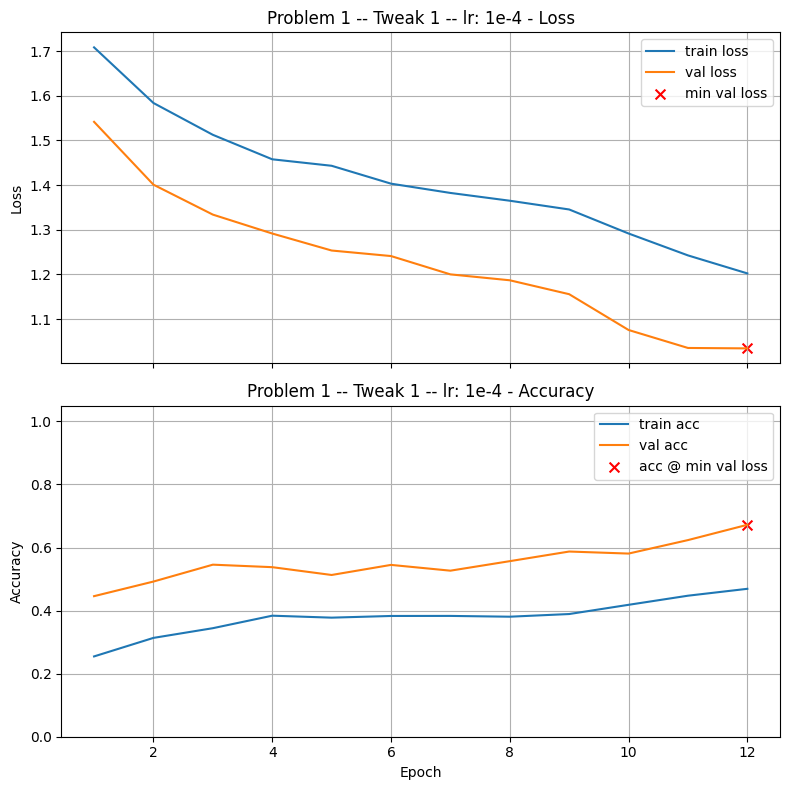

Final Training Loss:            1.2022
Final Training Accuracy:        0.4691
Final Validation Loss:          1.0344
Final Validation Accuracy:      0.6721
Minimum Validation Loss:        1.0344 (Epoch 12)
Validation Accuracy @ Min Loss: 0.6721

Test Accuracy: 0.6593
Baseline Model                          	0.8017	10
Problem 1 -- Tweak 1 -- lr: 1e-4        	0.6721	12


In [6]:
# Problem 1 -- Tweak 1 -- lr: 1e-4 (tf.data)

he = tf.keras.initializers.HeNormal()

model_p1_lr_1e4 = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_size[0], img_size[1], 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu", kernel_initializer=he),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

history_p1_lr_1e4, test_p1_lr_1e4 = train_and_test_ds(
    model_p1_lr_1e4,
    title="Problem 1 -- Tweak 1 -- lr: 1e-4",
    epochs=12,
    lr=1e-4,
    verbose=2
)

print_results()


## 1. Setup and Data Loading


In [1]:
%pip install -q scikit-learn

import os, time, random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split

# -------------------------
# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Suppress INFO/WARNING logs
print("TF:", tf.__version__)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


2026-02-17 23:08:28.836981: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-17 23:08:29.023154: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 23:08:32.226271: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF: 2.20.0


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}") 

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- `X_train,y_train,X_val,y_val,X_test,y_test` already defined, accessed here as global variables

In [2]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stopping point
                   lr_schedule   = 1e-3,                  # Adam default 
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 128,                  
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),      
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the Intel Image Classification Dataset  



In [2]:
import kagglehub
import os

path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test") 
import os, time, random
import numpy as np
import tensorflow as tf
import kagglehub
from tensorflow.keras.utils import image_dataset_from_directory

random_seed = 42
tf.keras.utils.set_random_seed(random_seed)

/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:

import os, random, time
import numpy as np
import tensorflow as tf
import kagglehub
from tensorflow.keras.utils import image_dataset_from_directory

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

# Settings (keep small for Codespaces stability)
img_size = (96, 96)
batch_size = 32

# Download + paths
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

print("path:", path)
print("train_dir exists?", os.path.exists(train_dir), train_dir)
print("test_dir exists? ", os.path.exists(test_dir),  test_dir)

# Load datasets
trainval_raw = image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=random_seed
)

test_raw = image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

# Save class names BEFORE mapping/prefetch
class_names = trainval_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Normalize + prefetch
def norm(x, y):
    return tf.cast(x, tf.float32) / 255.0, y

trainval_ds = trainval_raw.map(norm).prefetch(tf.data.AUTOTUNE)
test_ds     = test_raw.map(norm).prefetch(tf.data.AUTOTUNE)

# Train/val split by batches
card = tf.data.experimental.cardinality(trainval_ds).numpy()
val_batches = max(1, int(0.2 * card))
val_ds   = trainval_ds.take(val_batches)
train_ds = trainval_ds.skip(val_batches)

print("batches - train:", tf.data.experimental.cardinality(train_ds).numpy(),
      "val:", tf.data.experimental.cardinality(val_ds).numpy(),
      "test:", tf.data.experimental.cardinality(test_ds).numpy())

# Peek one batch (sanity check)
for images, labels in train_ds.take(1):
    print("Batch images:", images.shape, images.dtype,
          "min/max:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))
    print("Batch labels:", labels.shape, labels.dtype, "unique:", np.unique(labels.numpy()))
# --------------------------------------------


path: /home/codespace/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2
train_dir exists? True /home/codespace/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train
test_dir exists?  True /home/codespace/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test/seg_test
Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
batches - train: 352 val: 87 test: 94
Batch images: (32, 96, 96, 3) <dtype: 'float32'> min/max: 0.0 1.0
Batch labels: (32,) <dtype: 'int32'> unique: [0 1 2 3 4 5]


2026-02-17 23:13:05.168712: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [1]:
import os
import kagglehub

path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

print("train_dir:", train_dir)
print("test_dir:", test_dir)


/home/codespace/.python/current/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train_dir: /home/codespace/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train
test_dir: /home/codespace/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test/seg_test


In [3]:
# -------------------------
# tf.data pipeline
# -------------------------
import os, random, time
import numpy as np
import tensorflow as tf
import kagglehub
from tensorflow.keras.utils import image_dataset_from_directory

random_seed = 42
tf.keras.utils.set_random_seed(random_seed) 


img_size = (96, 96)   # smaller to avoid kernel crashes
batch_size = 32

trainval_raw = image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=random_seed
)

test_raw = image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = trainval_raw.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# normalize
def norm(x, y):
    return tf.cast(x, tf.float32) / 255.0, y

trainval_ds = trainval_raw.map(norm).prefetch(tf.data.AUTOTUNE)
test_ds     = test_raw.map(norm).prefetch(tf.data.AUTOTUNE)

# split train/val by batches
card = tf.data.experimental.cardinality(trainval_ds).numpy()
val_batches = max(1, int(0.2 * card))
val_ds   = trainval_ds.take(val_batches)
train_ds = trainval_ds.skip(val_batches)

print("batches - train:", tf.data.experimental.cardinality(train_ds).numpy(),
      "val:", tf.data.experimental.cardinality(val_ds).numpy(),
      "test:", tf.data.experimental.cardinality(test_ds).numpy())


Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
batches - train: 352 val: 87 test: 94


### Examine The Dataset

In [4]:
print("Classes:", class_names)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:  ", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches: ", tf.data.experimental.cardinality(test_ds).numpy())

# Peek at one batch
for images, labels in train_ds.take(1):
    print("One batch images shape:", images.shape)
    print("One batch labels shape:", labels.shape)



Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train batches: 352
Val batches:   87
Test batches:  94
One batch images shape: (32, 96, 96, 3)
One batch labels shape: (32,)


2026-02-17 23:29:08.098162: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


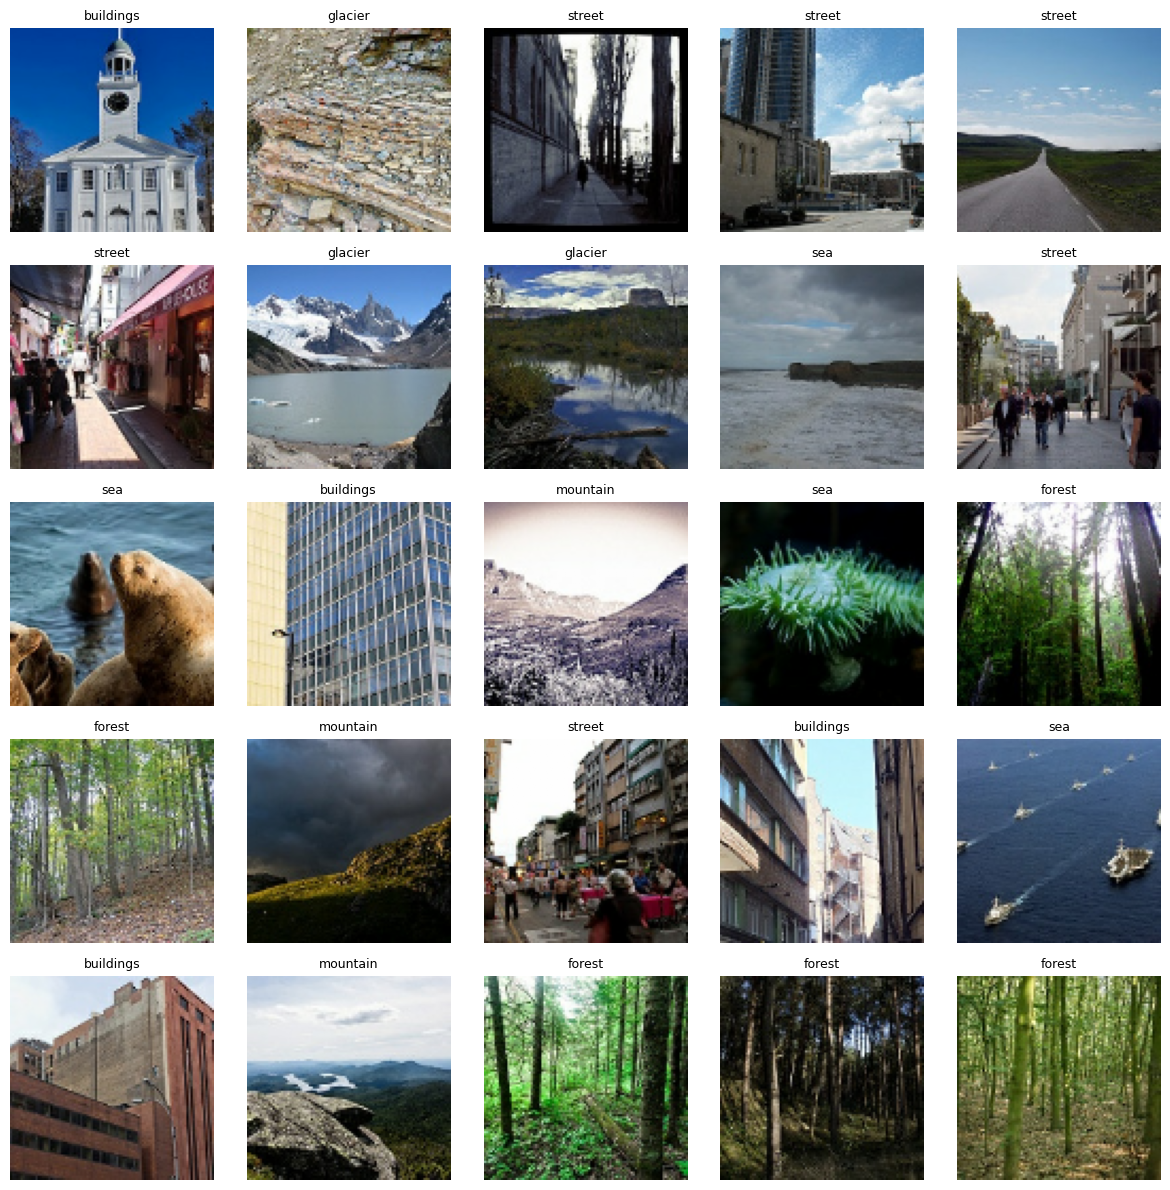

In [5]:
import matplotlib.pyplot as plt  # run once if not already imported

# Show a 5×5 grid of the first 25 training images from tf.data
plt.figure(figsize=(12, 12))

# Grab one batch from train_ds
images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy())
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Prelude: Baseline CNN (reference model)

This is our **reference** network: two Conv→Pool blocks with channels **32 → 64**, followed by a **single hidden head** `Dense(64)`. We use **He** initialization for ReLU activations and include an **optional `Dropout(0.5)`** to illustrate regularization—comment it out to gauge its impact (ha, not really optional!). 

Use this model as a stable yardstick while you run **ablations**: change **one knob at a time** (e.g., widen/deepen the conv blocks, adjust dropout rate, add batch norm, tweak the LR schedule) and compare results back to this baseline. Focus on **training vs. validation curves**, the **generalization gap**, and how dropout affects **val loss/accuracy** and how long it takes for Early Stopping to kick in. 


In [6]:
def train_and_test_ds(model, title="Model", epochs=30, lr=1e-3, verbose=2, extra_callbacks=None):
    if extra_callbacks is None:
        extra_callbacks = []

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=[early] + extra_callbacks,
        verbose=verbose
    )

    plot_learning_curves(history, title=title)

    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"\nTest Accuracy: {test_acc:.4f}")
    return history, float(test_acc)


In [7]:
# Baseline CNN (tf.data version)

import tensorflow as tf

he = tf.keras.initializers.HeNormal()

model_baseline = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_size[0], img_size[1], 3)),  # (96,96,3)

    tf.keras.layers.Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu", kernel_initializer=he),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

history, test_acc = train_and_test_ds(model_baseline, title="Baseline Model", epochs=30, lr=1e-3, verbose=2)
print_results()


Epoch 1/30


2026-02-17 23:29:32.298583: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37748736 exceeds 10% of free system memory.
2026-02-17 23:29:33.072094: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 26542080 exceeds 10% of free system memory.
2026-02-17 23:29:33.202491: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37748736 exceeds 10% of free system memory.
2026-02-17 23:29:33.300648: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 37748736 exceeds 10% of free system memory.
2026-02-17 23:29:33.424898: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 26542080 exceeds 10% of free system memory.


352/352 - 121s - 343ms/step - accuracy: 0.3467 - loss: 1.5556 - val_accuracy: 0.5603 - val_loss: 1.1286
Epoch 2/30
352/352 - 116s - 331ms/step - accuracy: 0.4544 - loss: 1.2810 - val_accuracy: 0.6196 - val_loss: 1.0300
Epoch 3/30
352/352 - 145s - 413ms/step - accuracy: 0.5203 - loss: 1.1285 - val_accuracy: 0.6699 - val_loss: 0.8644
Epoch 4/30
352/352 - 120s - 340ms/step - accuracy: 0.5821 - loss: 0.9810 - val_accuracy: 0.7342 - val_loss: 0.7883
Epoch 5/30
352/352 - 119s - 338ms/step - accuracy: 0.6361 - loss: 0.8991 - val_accuracy: 0.7403 - val_loss: 0.7658
Epoch 6/30
352/352 - 119s - 338ms/step - accuracy: 0.6827 - loss: 0.7997 - val_accuracy: 0.7755 - val_loss: 0.6811
Epoch 7/30
352/352 - 118s - 336ms/step - accuracy: 0.7114 - loss: 0.7426 - val_accuracy: 0.7845 - val_loss: 0.6547
Epoch 8/30
352/352 - 117s - 332ms/step - accuracy: 0.7446 - loss: 0.6478 - val_accuracy: 0.7924 - val_loss: 0.6168
Epoch 9/30
352/352 - 121s - 344ms/step - accuracy: 0.7692 - loss: 0.6052 - val_accuracy: 0.

NameError: name 'plot_learning_curves' is not defined

## BUT: Every couple of iterations, it does this!

Remember that initializations are random, even if controlled by HeNormal, so you may have exploding/disappearing gradients....a


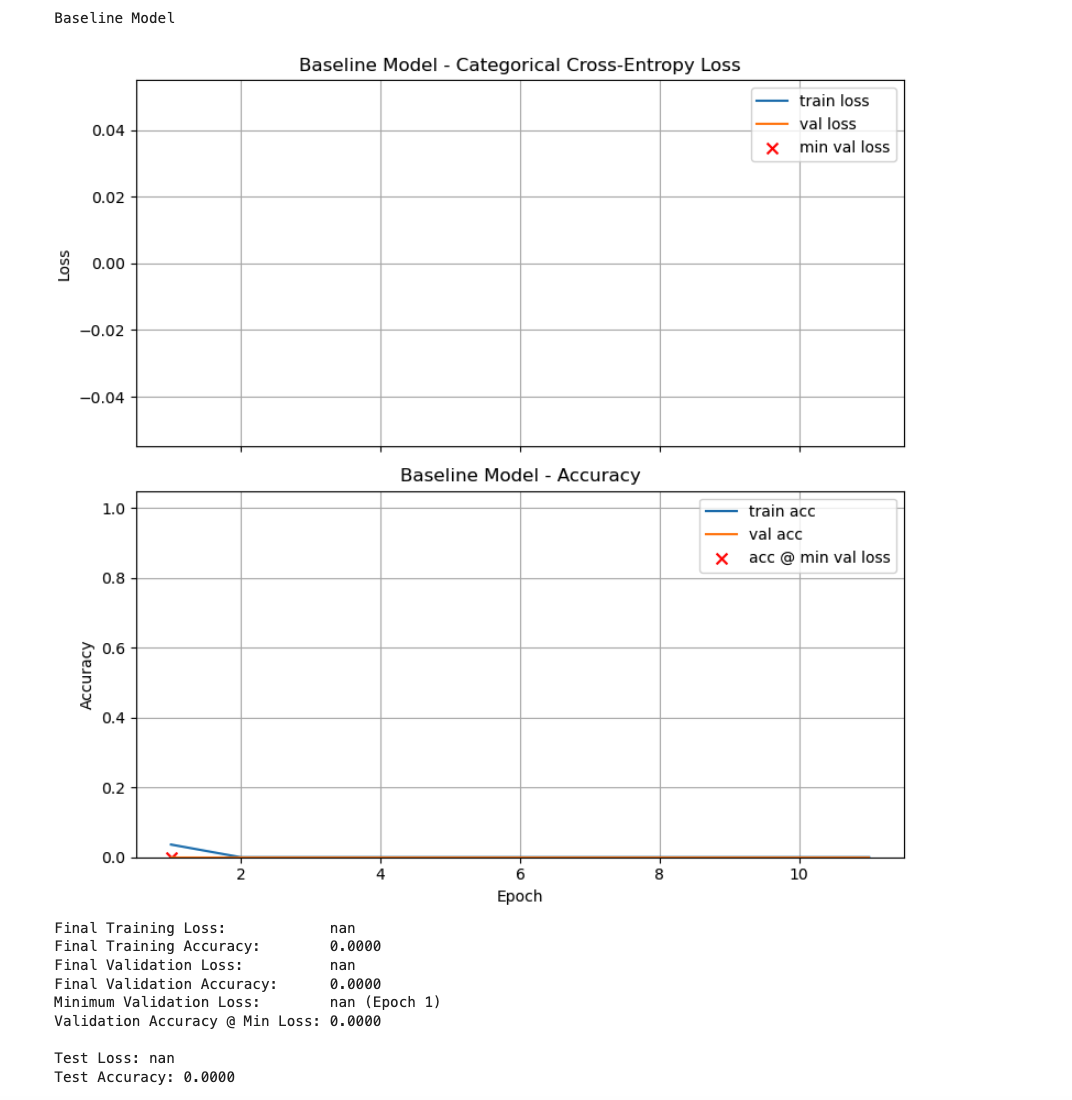

## Problem One: Exploring Basic Hyperparameters

**Task:**
Copy the baseline CNN model into the next cell and experiment with basic hyperparameter changes. Your goal is to see whether small tweaks can improve validation accuracy (and hopefully speed up convergence or produce smoother training curves). You must **pick 3 of the following tweaks** and investigate their effect:

**Tweaks to Try:**

1. Adjust the learning rate (default for Adam is `1e-3`).
2. Change the width of the `Conv2D` layers (e.g., 64 → 128).
3. Add an extra `Conv2D` layer (e.g., stack 32 → 64 → 128).
4. Change the width of the `Dense(64 ...)` layer. 
5. Add L2 regularization to the `Dense(64 ...)` layer (see the head of the network in Problem 5 for inspiration).  
6. Modify the dropout rate.
   
Observe the effect of each of your 3 choices in isolation and answer the graded questions.

**Optional:**
Combine two or more changes to see if they work together to improve results (example: try L2 regularization and reduced dropout in the head, as in Problem 5). 


**Pro Tip:** Give each experiment a descriptive title, such as "Problem 1 -- Tweak 1 -- lr: 0.0005" to keep track of your experiments (see last cell in the notebook).

In [ ]:
# Your code here, add additional cells if you wish

he = initializers.HeNormal()                                # best initializer for relu

model_baseline= models.Sequential([
    Input(shape=X_train.shape[1:]),

    Conv2D(32, (3,3), activation='relu', kernel_initializer=he, padding="same"),
    BatchNormalization(), 
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    MaxPooling2D(2),

    Flatten(),
    Dense(64, activation="relu",kernel_initializer=he), 
    
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

train_and_test(model_baseline,title="Baseline Model") 

Epoch 1/12
352/352 - 116s - 329ms/step - accuracy: 0.5414 - loss: 1.3440 - val_accuracy: 0.6753 - val_loss: 0.8925
Epoch 2/12
352/352 - 113s - 321ms/step - accuracy: 0.6772 - loss: 0.8520 - val_accuracy: 0.7198 - val_loss: 0.7353
Epoch 3/12
352/352 - 115s - 327ms/step - accuracy: 0.7470 - loss: 0.6806 - val_accuracy: 0.7647 - val_loss: 0.6535
Epoch 4/12
352/352 - 117s - 331ms/step - accuracy: 0.7974 - loss: 0.5614 - val_accuracy: 0.7636 - val_loss: 0.6623
Epoch 5/12
352/352 - 116s - 328ms/step - accuracy: 0.8347 - loss: 0.4512 - val_accuracy: 0.7848 - val_loss: 0.6262
Epoch 6/12
352/352 - 145s - 413ms/step - accuracy: 0.8716 - loss: 0.3537 - val_accuracy: 0.7953 - val_loss: 0.6484
Epoch 7/12
352/352 - 119s - 337ms/step - accuracy: 0.8911 - loss: 0.3023 - val_accuracy: 0.7676 - val_loss: 0.7490
Epoch 8/12
352/352 - 118s - 334ms/step - accuracy: 0.9123 - loss: 0.2442 - val_accuracy: 0.7863 - val_loss: 0.7826
Epoch 9/12
352/352 - 118s - 336ms/step - accuracy: 0.9315 - loss: 0.1950 - val_a

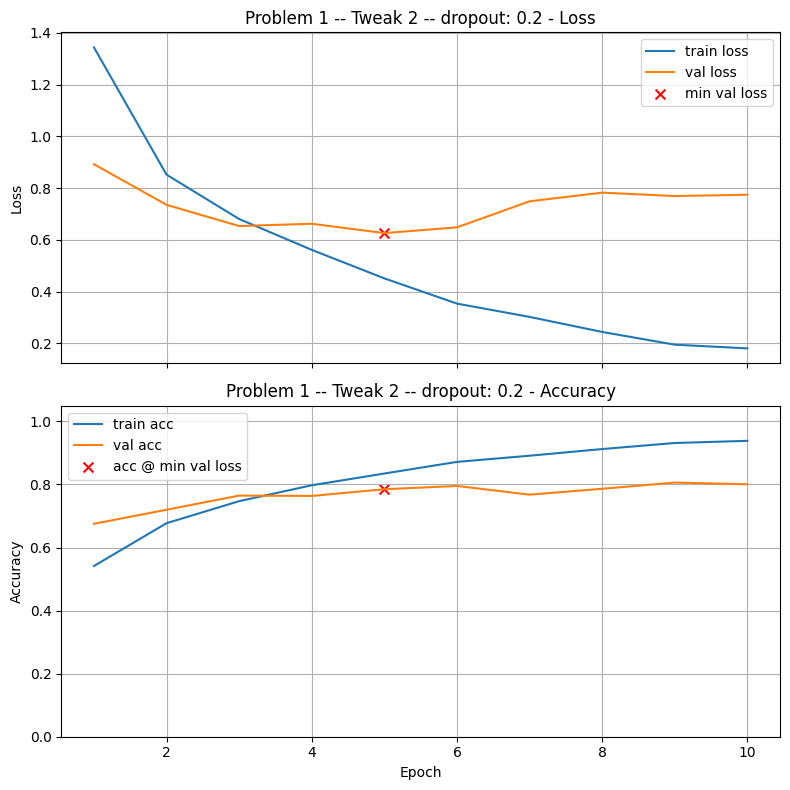

Final Training Loss:            0.1807
Final Training Accuracy:        0.9383
Final Validation Loss:          0.7745
Final Validation Accuracy:      0.8006
Minimum Validation Loss:        0.6262 (Epoch 5)
Validation Accuracy @ Min Loss: 0.7848

Test Accuracy: 0.7767
Baseline Model                          	0.8017	10
Problem 1 -- Tweak 2 -- dropout: 0.2    	0.7848	5
Problem 1 -- Tweak 1 -- lr: 1e-4        	0.6721	12


In [7]:
# Problem 1 -- Tweak 2 -- dropout: 0.2 (tf.data)

he = tf.keras.initializers.HeNormal()

model_p1_dropout_02 = tf.keras.models.Sequential([
    tf.keras.Input(shape=(img_size[0], img_size[1], 3)),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu", kernel_initializer=he, padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu", kernel_initializer=he),
    tf.keras.layers.Dropout(0.2),  # changed from 0.5
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

history_p1_dropout_02, test_p1_dropout_02 = train_and_test_ds(
    model_p1_dropout_02,
    title="Problem 1 -- Tweak 2 -- dropout: 0.2",
    epochs=12,
    lr=1e-3,
    verbose=2
)

print_results()


### Graded Questions

In [ ]:
# Set a1a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a1a = ...             # Replace with integer 1 - 6; replace with 0 if you found no tweak which improved the results

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = Ellipsis


In [ ]:
# Set a1b to the validation accuracy found by the choice specified in Question a1a. 

a1b = 0.0             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.0000


## Problem Two: Adding Batch Normalization

**Task:**
Take your best model from Problem One and add a `BatchNormalization()` layer immediately after each `Conv2D` layer. Batch normalization helps stabilize training and can improve convergence. 

**Next Steps:**

* Train the model with batch normalization included after each `Conv2D` layer. 
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare the results to your earlier experiments and answer the graded questions.

**Optional:**
Try more than one hyperparameter change alongside batch normalization and see how they interact.



In [ ]:
# Your code here, add additional cells if you wish



### Graded Questions

In [ ]:
# Set a2a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a2a = ...             # Replace with integer 1 - 6; replace with 0 if you found no tweak which improved the results

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 


a2a = Ellipsis


In [ ]:
# Set a2b to the validation accuracy found by the choice specified in Question a2a (your best model for this problem) 

a2b = 0.0             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.0000


## Problem Three: Global Average Pooling

As we saw in this week's Coding Video, 
**Global Average Pooling** is a simple layer that replaces the `Flatten → Dense` part of a CNN (please review that part of the Coding Notebook, which contains a description of this important technique). 

In practice, swapping `Flatten` for `GlobalAveragePooling2D` often improves stability and validation performance — definitely worth considering!


**Task:**
Modify your best model from Problems 1 & 2 to use a `GlobalAveragePooling2D()` layer instead of a flatten-and-dense block. 

**Next Steps:**

* Replace the sequence between the last `Conv2D` and output layers, for example:

     
          MaxPooling2D((2, 2)),
          Flatten(),
          Dense(64, activation='relu', kernel_initializer=initializers.HeNormal()),
          Dropout(0.5),   

  with a single `GlobalAveragePooling2D()` layer.
* Train the model and observe how performance and training curves change.
* Try at least one of tweaks from Problem 1 to see if you can improve your results in this new design. 
* Compare results and answer the graded questions.

**Optional:**
Experiment with `GlobalMaxPooling2D()` as an alternative and compare its behavior to `GlobalAveragePooling2D()`.



In [ ]:
# Your code here, add additional cells if you wish



### Graded Questions

In [ ]:
# Set a3a to the number of the individual "tweak" which provided the best validation accuracy at the epoch of minimum validation loss

a3a = ...             # Replace with integer 1 - 6; replace with 0 if you found no tweak which improved the results

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 


a3a = Ellipsis


In [ ]:
# Set a3b to the validation accuracy found by the choice specified in Question a3a (your best model for this problem) 

a3b = 0.0             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.0000


## Problem Four: ReduceLROnPlateau

`ReduceLROnPlateau` is a widely used learning rate scheduling technique. It monitors a validation metric (usually `val_loss`) and reduces the learning rate when progress stalls, allowing the model to refine training at a smaller step size. This is one of the most useful scheduling tools (along with the essential Early Stopping) to have in your toolbox.

**Task:**
Augment your best model found so far in Problems 1 - 3 with the `ReduceLROnPlateau` callback during training.

**Next Steps:**

* Add the callback parameter to `train_and_test`:

  ```python
  callbacks=[reduce_lr]
  ```

* Start with **`factor=0.5`** (monitor `val_loss`, `patience=2–3`, `cooldown=1`, `min_lr=1e-5` for Adam).
* **Practical playbook:**

  * If plateau persists after one reduction → try **`factor=0.3`**, then **`0.2`**.
  * If a reduction hurts validation noticeably → try **`factor=0.7–0.8`** or increase **`patience`**.
  * Leave **`cooldown=1`** unless you see too-frequent drops.
* Experiment with **`patience` = 3, 5, 8** and **`min_delta` = `1e-4` vs `1e-3`** to gauge sensitivity.
* Choose the configuration with the best validation results—or note that ReduceLROnPlateau didn’t help (rare!). 
* Answer the graded questions.



In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=1,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-5,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

# Your code here, add more cells as needed

### Graded Questions

In [ ]:
# Set a4a to the factor parameter which gave the best validation accuracy at the point of minimum validation loss

a4a = 0.0             # Replace with your best factor value, or leave at 0.0 if reduce on plateau did not help at all

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.2f}') 

a4a = 0.00


In [ ]:
# Set a4b to the validation accuracy found by the choice specified in Question a4a (your best model for this problem) 

a4b = 0.0             # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.0000


## Problem Five: A Very Deep CNN (VGG-16 Style)

 We will now experiment with the VGG-16 design introduced in the Coding Notebook and Video and see how it does on this dataset. For a beautiful description of the model and its significance, see [Explanation of VGG-16](https://viso.ai/deep-learning/vgg-very-deep-convolutional-networks/) :
        

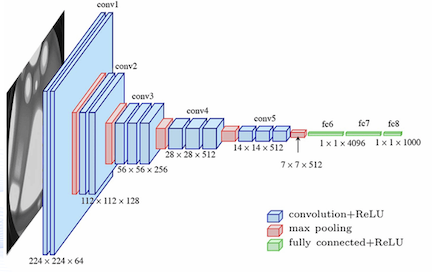


In this exercise you’ll **only vary the learning rate**. Don’t change any other hyperparameters. Your goal is to observe how LR affects convergence speed, stability, and final validation performance compared to your smaller baselines. This sets up next week’s **transfer learning** with pretrained models.

#### Starting point

* Optimizer: **Adam**
* **Recommended LR to start:** `1e-3`(Adam default)

#### What LR values to try (coarse → fine)

Try a short sweep like:

```
[1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
```

Then, as time allows,  zoom in around the best.

#### How to judge “best”

* Primary: **best validation accuracy at epoch of lowest validation loss** 
* Secondary: **time-to-best** (fewer epochs to reach a strong val metric) and **curve shape** (smooth vs. noisy/oscillatory).

#### What symptoms mean

* **LR too high:** training loss spikes or oscillates; val metrics erratic, occasional NaNs/divergence.
* **LR too low:** very slow improvement; long flat regions; never reaches your smaller models’ performance.


**Tip:** Keep LR **constant** during each run (don’t schedule) so you isolate its effect. 



In [ ]:
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)   # set to None to disable or tweak the value

model_vgg_16 = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(256, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.MaxPooling2D(),

    # Block 4 (NO MaxPool here -> leaves 3×3×512)
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),
    layers.Conv2D(512, (3,3), padding='same', activation='relu', kernel_initializer=he),

    # Global pooling meaningfully summarizes the 3×3 map
    layers.GlobalAveragePooling2D(),   # swap to GlobalMaxPooling2D() to compare

    # Compact head
    layers.Dense(256, activation='relu', kernel_initializer=he,
                 kernel_regularizer=l2reg),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Uncomment the next line to run

train_and_test(model_vgg_16,lr_schedule=1e-3,title="VGG-style Large")


### Graded Questions

In [ ]:
# Set a5a to the learning rate which gave the best validation accuracy at the point of minimum validation loss

a5a = 0.0             # Replace with your best learning rate

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.8f}') 

a5a = 0.00000000


In [ ]:
# Set a5b to the validation accuracy found by the choice specified in Question a5a (your best model for this problem) 

a5b = 0.0              # Replace 0.0 with your answer           

In [ ]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.0000


## All Results

This will print out the results from all experiments, with titles as keys. I use this all the time to keep track of experiments!

In [ ]:
print_results()

Baseline Model                          	0.0000	1


    VGG-style Large -- lr: 0.0001           	0.8700	18
    Model with ReduceLROnPlateau            	0.8636	227
    VGG-style Large -- lr: 0.0003           	0.8400	23
    VGG-style Large -- lr: 1e-05            	0.8301	60
    VGG-style Large -- lr: 3e-05            	0.8269	26
    Baseline model using BatchNormalization -- Tweak 2 -- 64 -> 128	0.8140	33
    Baseline Plus -- Tweaks 5 & 6 -- Do: 0.3	0.8030	50
    Baseline model using BatchNormalization -- Tweak 3 -- 32 -> 64 -> 128	0.8019	26
    Baseline model using BatchNormalization -- Tweak 4 -- Dense 128	0.7976	24
    Baseline model using BatchNormalization 	0.7941	7
    Baseline Plus -- Tweak 3 -- 32 -> 64 -> 128	0.7912	20
    Baseline Plus -- Tweak 6 -- Do: 0.3     	0.7745	36
    Baseline Plus -- Tweak 2 -- 64 -> 128   	0.7645	25
    Baseline Plus -- Tweak 5 -- L2: 1e-4    	0.7570	27
    Model using GAP                         	0.7553	10
    Baseline Plus -- Two Tweaks! -- L2: 1e-4 Do: 0.3	0.7506	19
    VGG-style Large -- lr: 0.001            	0.6865	5
    Baseline Plus -- Tweak 4 -- Dense 128   	0.5999	1
    Baseline Plus -- Tweak 1 -- lr: 1e-4    	0.4817	3
    Baseline model using BatchNormalization -- Tweak 1 lr: 0.0001 	0.3691	1
    VGG-style Large -- lr: 0.01             	0.1792	95
    VGG-style Large -- lr: 0.003            	0.1792	195
    Baseline Model                          	0.0000	1